In [1]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from typing import Annotated, Sequence, TypedDict
from langchain_core.messages import BaseMessage # The foundational class for all message types in LangGraph
from langchain_core.messages import ToolMessage # Passes data back to LLM after it calls a tool such as the content and the tool_call_id
from langchain_core.messages import SystemMessage # Message for providing instructions to the LLM
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, END
from langgraph.prebuilt import ToolNode
from langchain_groq import ChatGroq  # 👈 Use this instead of ChatOpenAI
from typing import Dict, TypedDict


In [16]:
# Groq LLM (change model if needed)
llm = ChatGroq(
    model="openai/gpt-oss-120b",   # 👈 Replace with your desired Groq model
    api_key=""
)

In [17]:
from typing import TypedDict, Optional, List

class AgentState(TypedDict):
    user_input: str
    intent: Optional[str]
    memory: List[str]
    sql: Optional[str]
    sql_result: Optional[str]
    valid: Optional[bool]
    retry_count: int
    final_answer: Optional[str]

In [18]:
def agent(state):
    return state


In [19]:
def intent_classifier(state):
    intent = llm.invoke(f"Classify intent: SQL / CHAT / DOC\nUser: {state['user_input']}").content
    return {**state, "intent": intent.strip()}


In [20]:
def text_to_sql_agent(state):
    prompt = f"""
    Use DB schema and memory to generate SQL.
    Memory: {state['memory']}
    User: {state['user_input']}
    """
    sql = llm.invoke(prompt).content
    return {**state, "sql": sql}


In [21]:
def memory_agent(state):
    memory = state.get("memory", [])
    memory.append(state["user_input"])
    return {**state, "memory": memory}


In [22]:
MAX_RETRY = 3

def validate_sql(state):
    try:
        result = run_sql(state["sql"])  # your db executor
        return {**state, "sql_result": result, "valid": True}
    except Exception as e:
        state["retry_count"] += 1
        return {**state, "valid": False}


In [23]:
def should_retry(state):
    if not state["valid"] and state["retry_count"] < MAX_RETRY:
        return "retry"
    return "done"


In [24]:
def summarizer(state):
    prompt = f"Summarize this SQL result for user:\n{state['sql_result']}"
    answer = llm.invoke(prompt).content
    return {**state, "final_answer": answer}


In [25]:
graph = StateGraph(AgentState)

graph.add_node("agent", agent)
graph.add_node("intent_classifier", intent_classifier)
graph.add_node("memory_node", memory_agent)
graph.add_node("sql_generator", text_to_sql_agent)
graph.add_node("validator", validate_sql)
graph.add_node("summarizer", summarizer)

graph.set_entry_point("agent")

graph.add_edge("agent", "intent_classifier")

graph.add_conditional_edges(
    "intent_classifier",
    lambda s: "sql" if s["intent"] == "SQL" else "end",
    {
        "sql": "memory_node",
        "end": END
    }
)

graph.add_edge("memory_node", "sql_generator")
graph.add_edge("sql_generator", "validator")

graph.add_conditional_edges(
    "validator",
    should_retry,
    {
        "retry": "sql_generator",
        "done": "summarizer"
    }
)

graph.add_edge("summarizer", END)

app = graph.compile()


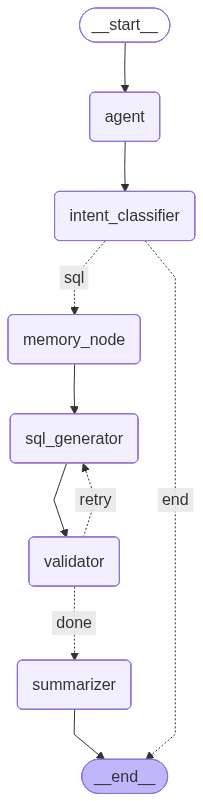

In [26]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [27]:
state = {
    "user_input": "How many invoices were created in January 2025?",
    "intent": None,
    "memory": [],
    "sql": None,
    "sql_result": None,
    "valid": None,
    "retry_count": 0,
    "final_answer": None
}

result = app.invoke(state)


In [28]:
result

{'user_input': 'How many invoices were created in January 2025?',
 'intent': 'SQL',
 'memory': ['How many invoices were created in January 2025?'],
 'sql': "**SQL Query**\n\n```sql\nSELECT COUNT(*) AS invoice_count\nFROM invoices\nWHERE created_at >= '2025-01-01'\n  AND created_at <  '2025-02-01';\n```\n\n*Explanation*: This counts all rows in the `invoices` table whose `created_at` timestamp falls within January\u202f2025 (from the start of 2025‑01‑01 up to, but not including, 2025‑02‑01).",
 'sql_result': None,
 'valid': False,
 'retry_count': 3,
 'final_answer': '**Summary:** The query returned **no results**—there are no rows to display. This could mean that the table is empty, the filter criteria didn’t match any records, or the data simply doesn’t exist for the requested parameters. If you expected data, you may want to double‑check the query conditions, table name, or data source.'}